# Analyse recall end-to-end predictions

Score Qwen3.5 0.8b / 2b / 4b through the full recall path:
cached query-understanding plan, then hybrid retrieve, then LLM filter.

Keep the three query buckets separate:
- `in_scope_nonempty` : ids 1-39, at least one expected contact
- `in_scope_empty` : ids 40-49, in-scope but no expected contacts
- `oos` : ids 50-60, out of scope

Metrics:
- nonempty: `macro_precision`, `macro_recall`, `macro_f1` on `contact_ids` vs expected
- empty: `correct_empty_rate`
- oos: `oos_correct_rate`, `oos_leak_rate`
- all 60: `mean_returned_count` and per-stage latency
- `fail_stage` on the 39: first stage that made the answer wrong

Write `eval/results/recall_e2e_results.csv`, then visualise.


## 0. Setup


In [104]:
# %pip install -q pandas matplotlib

In [105]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Navigate up until eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "recall" / "recall_queries.jsonl"
PRED_DIR = REPO_ROOT / "eval" / "predictions" / "recall_e2e"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "recall_e2e_results.csv"

MODEL_ORDER = ["qwen3.5_4b", "qwen3.5_2b", "qwen3.5_0.8b"]

# Query buckets to score separately
# Queries 1–39: non-empty is expected
NONEMPTY_BUCKET = "in_scope_nonempty"
# queries 40–49: no matching contact is expected
EMPTY_BUCKET = "in_scope_empty"
# queries 50–60: not a contact search (out of scope is expected)
OOS_BUCKET = "oos"
# all 60 queries, used for latency and mean returned count.
ALL_BUCKET = "all"

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED_DIR:", PRED_DIR.exists(), PRED_DIR)
if PRED_DIR.exists():
    print("prediction files:", sorted(p.name for p in PRED_DIR.glob("*.jsonl")))


REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/recall/recall_queries.jsonl
PRED_DIR: True /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions/recall_e2e
prediction files: ['qwen3.5_0.8b.jsonl', 'qwen3.5_2b.jsonl', 'qwen3.5_4b.jsonl']


## 1. Load

Read all 60 GT rows, join each model's e2e predictions on `id`, and label the three buckets from ground truth.


In [106]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows


def contact_id_list(raw) -> list[int]:
    """
    Keep contact ids that parse as integers.
    """
    ids: list[int] = []
    for item in raw or []:
        try:
            # Convert to int and add to list
            ids.append(int(item))
        except (TypeError, ValueError):
            continue
    return ids


def row_has_error(error) -> bool:
    """
    Check whether the prediction stored a real error string.
    """
    if error is None:
        return False
    # Pandas stores a null error as NaN
    if isinstance(error, float) and math.isnan(error):
        return False
    return True


def query_bucket(expected: dict) -> str:
    """
    Bucket a GT row from in-scope, in-scope with no expected contacts, or out of scope
    """
    # Out-of-scope questions
    if expected.get("in_scope") is not True:
        return OOS_BUCKET
    # In-scope with no expected contacts
    if not contact_id_list(expected.get("contact_ids")):
        return EMPTY_BUCKET
    return NONEMPTY_BUCKET


def unpack_latency(raw) -> dict:
    """
    Pull per-stage latency out of the prediction dict
    Skipped stages stay None
    """
    if not isinstance(raw, dict):
        total = raw if isinstance(raw, (int, float)) else None
        return {
            "latency_ms_qu": None,
            "latency_ms_retrieve": None,
            "latency_ms_filter": None,
            "latency_ms_total": total,
        }

    # Engines write query_understanding. Accept qu as a fallback
    qu_ms = raw.get("query_understanding", raw.get("qu"))
    retrieve_ms = raw.get("retrieve")
    filter_ms = raw.get("filter")
    total_ms = raw.get("total")
    return {
        "latency_ms_qu": qu_ms if isinstance(qu_ms, (int, float)) else None,
        "latency_ms_retrieve": retrieve_ms if isinstance(retrieve_ms, (int, float)) else None,
        "latency_ms_filter": filter_ms if isinstance(filter_ms, (int, float)) else None,
        "latency_ms_total": total_ms if isinstance(total_ms, (int, float)) else None,
    }


# Ground truth indexed by query id, used to join predictions
gt_by_id = {int(row["id"]): row for row in load_jsonl(GT_PATH)}

# Load each model's predictions and join GT on id
joined_rows: list[dict] = []
for model in MODEL_ORDER:
    # Get prediction path for each model
    pred_path = PRED_DIR / f"{model}.jsonl"
    if not pred_path.is_file():
        print(f"missing: {pred_path}")
        continue

    for pred in load_jsonl(pred_path):
        query_id = int(pred["id"])
        gt = gt_by_id.get(query_id)

        # Skip prediction rows with no matching ground truth
        if gt is None:
            continue
        expected = gt.get("expected") or {}
        plan = pred.get("plan") or {}
        latency = unpack_latency(pred.get("latency_ms"))
        expected_ids = contact_id_list(expected.get("contact_ids"))
        candidate_ids = contact_id_list(pred.get("candidate_ids"))
        predicted_ids = contact_id_list(pred.get("contact_ids"))
        joined_rows.append(
            {
                "model": model,
                "id": query_id,
                "query": gt.get("query", ""),
                "bucket": query_bucket(expected),
                "gt_in_scope": bool(expected.get("in_scope")),
                "pred_in_scope": bool(plan.get("in_scope", False)),
                "status": pred.get("status"),
                "expected_ids": expected_ids,
                "n_expected": len(expected_ids),
                "candidate_ids": candidate_ids,
                "n_candidates": len(candidate_ids),
                "fts_ids": contact_id_list(pred.get("fts_ids")),
                "vector_ids": contact_id_list(pred.get("vector_ids")),
                "predicted_ids": predicted_ids,
                "n_predicted": len(predicted_ids),
                "error": pred.get("error"),
                **latency,
            }
        )

# Handle missing predictions
if not joined_rows:
    raise FileNotFoundError(
        f"No prediction JSONL in {PRED_DIR}. "
        "Run: python eval/scripts/recall_e2e/run_recall_e2e_eval.py --model all"
    )

# Convert joined rows into a DataFrame
raw = pd.DataFrame(joined_rows)
print(raw.shape)
raw.head()

(180, 20)


,model,id,query,bucket,gt_in_scope,pred_in_scope,status,expected_ids,n_expected,candidate_ids,n_candidates,fts_ids,vector_ids,predicted_ids,n_predicted,error,latency_ms_qu,latency_ms_retrieve,latency_ms_filter,latency_ms_total
0,qwen3.5_4b,1,who likes hiking,in_scope_nonempty,True,True,ok,"[1, 48, 50, 87, 107, 132, 140, 143]",8,"[125, 1, 107, 110, 4, 28, 15, 77, 99, 82, 83, ...",22,"[1, 48, 107, 143]","[125, 1, 107, 110, 4, 28, 15, 77, 99, 82, 83, ...","[1, 107, 48]",3,NaN,8931.57,665.70,13986.32,23583.59
1,qwen3.5_4b,2,who boulders or climbs,in_scope_nonempty,True,True,no_matches,"[4, 5, 25, 27, 44, 55, 62, 68, 77, 82, 98, 113...",16,"[128, 77, 113, 5, 82, 62, 144, 44, 4, 107, 118...",22,"[62, 5, 118, 44, 55, 68, 77, 82, 98, 113, 128,...","[128, 77, 113, 5, 82, 62, 144, 44, 4, 107, 118...",[],0,NaN,3232.73,1272.46,7754.10,12259.29
2,qwen3.5_4b,3,who works in fintech,in_scope_nonempty,True,True,ok,"[3, 4, 44, 58, 67, 98, 105, 115]",8,"[98, 4, 58, 80, 105, 2, 76, 115, 3, 56, 44, 99...",20,"[3, 4, 58, 98, 105]","[98, 4, 58, 80, 105, 2, 76, 115, 3, 56, 44, 99...","[98, 4, 58, 105, 3, 115, 44, 67]",8,NaN,3010.11,411.88,8375.99,11797.98
3,qwen3.5_4b,4,who is a product designer,in_scope_nonempty,True,True,ok,"[20, 42, 79, 101, 113, 116, 138, 139]",8,"[20, 42, 138, 131, 2, 79, 116, 88, 123, 80, 74...",20,"[42, 20, 79, 139]","[20, 42, 138, 131, 2, 79, 116, 88, 123, 80, 74...","[20, 42, 79]",3,NaN,2810.08,366.04,7602.69,10778.81
4,qwen3.5_4b,5,who did I meet at the career fair,in_scope_nonempty,True,True,ok,"[1, 2, 55, 56, 67, 76]",6,"[90, 67, 56, 98, 125, 76, 4, 79, 28, 142, 138,...",32,"[76, 39, 67, 56, 2, 1, 55, 98, 83, 105, 60, 66...","[90, 67, 56, 98, 125, 76, 4, 79, 28, 142, 138,...","[67, 56]",2,NaN,3248.98,309.82,11423.37,14982.17


## 2. Score each row

Nonempty in-scope (true e2e overlap, not pool-conditioned):
- **macro_precision** : how many returned contacts were expected
- **macro_recall** : how many expected contacts were returned
- **macro_f1** : harmonic mean of those two
- Empty prediction on a non-empty expected query: precision 0, recall 0

Empty in-scope:
- **correct_empty** : `contact_ids` is empty (user sees no contacts)

Out of scope:
- **oos_correct** : predicted `in_scope` is false
- **oos_leak** : returned at least one contact

`fail_stage` on the 39, first mismatch:
- `qu_error` : cached QU row stored an error
- `qu_false_oos` : predicted out of scope
- `retrieve_miss` : at least one expected id missing from `candidate_ids`
- `filter_drop` : pool had all expected ids, filter dropped some
- `filter_extra` : expected set exact, extras added
- `ok`


In [107]:
def set_pred_recall_f1(expected: set[int], predicted: set[int]) -> tuple[float, float, float]:
    """
    Output the precision, recall, and F1 on contact-id sets
    Empty prediction against non-empty expected is 0, 0, 0
    """
    # No expected contacts: P/R/F1 are not defined for this bucket
    if not expected:
        return float("nan"), float("nan"), float("nan")
    # Missed the query entirely
    if not predicted:
        return 0.0, 0.0, 0.0

    overlap = len(expected & predicted)
    precision = overlap / len(predicted)
    recall = overlap / len(expected)
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0.0
    )
    return precision, recall, f1


def fail_stage_for_row(row: pd.Series) -> str | None:
    """
    First stage that made a nonempty in-scope answer wrong
    Empty and out-of-scope rows skip this and get None
    """
    # Only the 39 nonempty in-scope queries get a fail_stage
    if row["bucket"] != NONEMPTY_BUCKET:
        return None

    expected = set(row["expected_ids"])
    candidates = set(row["candidate_ids"])
    predicted = set(row["predicted_ids"])
    retrieve_ms = row["latency_ms_retrieve"]
    retrieve_ran = isinstance(retrieve_ms, (int, float)) and not (
        isinstance(retrieve_ms, float) and math.isnan(retrieve_ms)
    )

    # QU error or predicted out of scope
    if not retrieve_ran:
        if row_has_error(row["error"]) and row["status"] == "error":
            return "qu_error"
        return "qu_false_oos"

    # At least one expected contact never entered the merged pool
    if expected - candidates:
        return "retrieve_miss"

    # Pool had every expected id but filter dropped some of them
    if expected - predicted:
        return "filter_drop"

    # Extra contacts were added
    if predicted - expected:
        return "filter_extra"

    return "ok"


def score_row(row: pd.Series) -> dict:
    """
    Score one e2e prediction against expected contact ids and scope.
    """
    expected = set(row["expected_ids"])
    candidates = set(row["candidate_ids"])
    predicted = set(row["predicted_ids"])
    precision, recall, f1 = set_pred_recall_f1(expected, predicted)

    # How many expected ids are already in candidate_ids (merged pool)
    pool_recall = (len(expected & candidates) / len(expected)) if expected else float("nan")

    return {
        "model": row["model"],
        "id": row["id"],
        "query": row["query"],
        "bucket": row["bucket"],
        "status": row["status"],
        "pred_in_scope": row["pred_in_scope"],
        "n_expected": row["n_expected"],
        "n_candidates": row["n_candidates"],
        "n_predicted": row["n_predicted"],
        "latency_ms_qu": row["latency_ms_qu"],
        "latency_ms_retrieve": row["latency_ms_retrieve"],
        "latency_ms_filter": row["latency_ms_filter"],
        "latency_ms_total": row["latency_ms_total"],
        "error": row["error"],
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "pool_recall": pool_recall,
        "correct_empty": float(row["n_predicted"] == 0),
        "oos_correct": float(not row["pred_in_scope"]),
        "oos_leak": float(row["n_predicted"] > 0),
        "fail_stage": fail_stage_for_row(row),
    }


# Convert scores into DataFrame
scored = pd.DataFrame([score_row(row) for _, row in raw.iterrows()])
print(scored.shape)
scored.head()

(180, 22)


,model,id,query,bucket,status,pred_in_scope,n_expected,n_candidates,n_predicted,latency_ms_qu,...,latency_ms_total,error,macro_precision,macro_recall,macro_f1,pool_recall,correct_empty,oos_correct,oos_leak,fail_stage
0,qwen3.5_4b,1,who likes hiking,in_scope_nonempty,ok,True,8,22,3,8931.57,...,23583.59,NaN,1.0,0.375000,0.545455,0.50,0.0,0.0,1.0,retrieve_miss
1,qwen3.5_4b,2,who boulders or climbs,in_scope_nonempty,no_matches,True,16,22,0,3232.73,...,12259.29,NaN,0.0,0.000000,0.000000,1.00,1.0,0.0,0.0,filter_drop
2,qwen3.5_4b,3,who works in fintech,in_scope_nonempty,ok,True,8,20,8,3010.11,...,11797.98,NaN,1.0,1.000000,1.000000,1.00,0.0,0.0,1.0,ok
3,qwen3.5_4b,4,who is a product designer,in_scope_nonempty,ok,True,8,20,3,2810.08,...,10778.81,NaN,1.0,0.375000,0.545455,0.75,0.0,0.0,1.0,retrieve_miss
4,qwen3.5_4b,5,who did I meet at the career fair,in_scope_nonempty,ok,True,6,32,2,3248.98,...,14982.17,NaN,1.0,0.333333,0.500000,1.00,0.0,0.0,1.0,filter_drop


## 3. Aggregate

Macro-average each metric inside its bucket:

| bucket | metric | how |
|---|---|---|
| `in_scope_nonempty` | `macro_precision` | mean over the 39: returned ids that were expected |
| `in_scope_nonempty` | `macro_recall` | mean over the 39: expected ids that were returned |
| `in_scope_nonempty` | `macro_f1` | mean over the 39: harmonic mean of those two |
| `in_scope_nonempty` | `pool_recall` | mean over the 39: expected ids in `candidate_ids` |
| `in_scope_empty` | `correct_empty_rate` | fraction with empty `contact_ids` |
| `oos` | `oos_correct_rate` | predicted `in_scope == false` |
| `oos` | `oos_leak_rate` | non-empty `contact_ids` |
| `all` | `mean_returned_count` | mean `len(contact_ids)` |
| `all` | `latency_ms_mean` | mean total latency over all 60 |
| `all` | `latency_ms_qu` | mean query-understanding latency over queries that ran it |
| `all` | `latency_ms_retrieve` | mean retrieve latency over queries that ran it |
| `all` | `latency_ms_filter` | mean filter latency over queries that ran it |


In [108]:
def mean_metric(df: pd.DataFrame, column: str) -> tuple[float | None, int]:
    """
    Mean of a metric column, ignoring missing values
    """
    # Convert to float and exclude NaN rows
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    if values.empty:
        return None, 0
    return float(values.mean()), int(len(values))


def bucket_latency_mean(frame: pd.DataFrame) -> float | None:
    """
    Mean total latency for a (model, bucket) slice
    """
    value, n = mean_metric(frame, "latency_ms_total")
    return value if n else None


def append_metric_row(
    rows: list[dict],
    model: str,
    bucket: str,
    metric: str,
    frame: pd.DataFrame,
    column: str,
    latency_mean: float | None,
) -> None:
    """
    Mean one column and append it as a long-format result row
    """
    value, n = mean_metric(frame, column)
    rows.append(
        {
            "model": model,
            "bucket": bucket,
            "metric": metric,
            "value": value,
            "n": n,
            "latency_ms_mean": latency_mean,
        }
    )


models = [m for m in MODEL_ORDER if m in set(scored["model"])]
result_rows: list[dict] = []

for model in models:
    # Scored rows for the current model
    model_rows = scored[scored["model"] == model]
    nonempty = model_rows[model_rows["bucket"] == NONEMPTY_BUCKET]
    empty = model_rows[model_rows["bucket"] == EMPTY_BUCKET]
    oos = model_rows[model_rows["bucket"] == OOS_BUCKET]

    # Mean latency for each bucket
    nonempty_lat = bucket_latency_mean(nonempty)
    empty_lat = bucket_latency_mean(empty)
    oos_lat = bucket_latency_mean(oos)
    all_lat = bucket_latency_mean(model_rows)

    # 39 in-scope queries that expect contacts
    append_metric_row(result_rows, model, NONEMPTY_BUCKET, "macro_precision", nonempty, "macro_precision", nonempty_lat)
    append_metric_row(result_rows, model, NONEMPTY_BUCKET, "macro_recall", nonempty, "macro_recall", nonempty_lat)
    append_metric_row(result_rows, model, NONEMPTY_BUCKET, "macro_f1", nonempty, "macro_f1", nonempty_lat)
    append_metric_row(result_rows, model, NONEMPTY_BUCKET, "pool_recall", nonempty, "pool_recall", nonempty_lat)

    # 10 in-scope queries that expect no contacts
    append_metric_row(result_rows, model, EMPTY_BUCKET, "correct_empty_rate", empty, "correct_empty", empty_lat)

    # 11 out-of-scope queries
    append_metric_row(result_rows, model, OOS_BUCKET, "oos_correct_rate", oos, "oos_correct", oos_lat)
    append_metric_row(result_rows, model, OOS_BUCKET, "oos_leak_rate", oos, "oos_leak", oos_lat)

    # All 60 queries
    append_metric_row(result_rows, model, ALL_BUCKET, "mean_returned_count", model_rows, "n_predicted", all_lat)
    append_metric_row(result_rows, model, ALL_BUCKET, "latency_ms_mean", model_rows, "latency_ms_total", all_lat)
    append_metric_row(result_rows, model, ALL_BUCKET, "latency_ms_qu", model_rows, "latency_ms_qu", all_lat)
    append_metric_row(result_rows, model, ALL_BUCKET, "latency_ms_retrieve", model_rows, "latency_ms_retrieve", all_lat)
    append_metric_row(result_rows, model, ALL_BUCKET, "latency_ms_filter", model_rows, "latency_ms_filter", all_lat)

# Convert long-format metric rows into a DataFrame
results = pd.DataFrame(result_rows)
results

,model,bucket,metric,value,n,latency_ms_mean
0,qwen3.5_4b,in_scope_nonempty,macro_precision,0.825203,39,13164.642564
1,qwen3.5_4b,in_scope_nonempty,macro_recall,0.553006,39,13164.642564
2,qwen3.5_4b,in_scope_nonempty,macro_f1,0.612549,39,13164.642564
3,qwen3.5_4b,in_scope_nonempty,pool_recall,0.806967,39,13164.642564
4,qwen3.5_4b,in_scope_empty,correct_empty_rate,0.500000,10,16663.480000
5,qwen3.5_4b,oos,oos_correct_rate,0.818182,11,4760.654545
6,qwen3.5_4b,oos,oos_leak_rate,0.181818,11,4760.654545
7,qwen3.5_4b,all,mean_returned_count,2.833333,60,12207.051000
8,qwen3.5_4b,all,latency_ms_mean,12207.051000,60,12207.051000
9,qwen3.5_4b,all,latency_ms_qu,3477.597833,60,12207.051000


## 4. Save

Overwrite `eval/results/recall_e2e_results.csv`.


In [109]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Convert results df to CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")


Wrote 36 rows to eval/results/recall_e2e_results.csv


## 5. Visualisation

1. `in_scope_nonempty` (n=39) metrics (`macro_precision`, `macro_recall`, `macro_f1`, `pool_recall`)
2. `in_scope_empty` (n=10) `correct_empty_rate`
3. `out_of_scope` (n=11) metrics (`oos_correct_rate`, `oos_leak_rate`)
4. `all` (n=60) metrics (latency share, `mean_returned_count`)


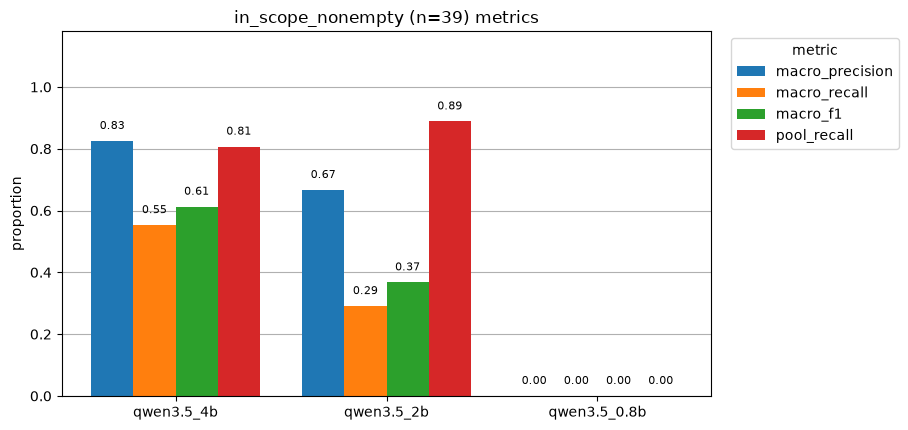

In [110]:
def pivot_bucket(bucket: str, metrics: list[str]) -> pd.DataFrame:
    """
    Models as rows, named metrics as columns, from the long-format results table
    """
    plot_df = results[(results["bucket"] == bucket) & (results["metric"].isin(metrics))]
    pivot = plot_df.pivot(index="model", columns="metric", values="value")
    return pivot.reindex(index=models, columns=metrics)


def plot_grouped_rates(
    ax,
    pivot: pd.DataFrame,
    *,
    title: str,
    colours: dict[str, str] | None = None,
) -> None:
    """
    Independent rates as grouped bars
    """
    metric_names = list(pivot.columns)
    n_metrics = len(metric_names)
    xs = list(range(len(models)))
    width = min(0.8 / max(n_metrics, 1), 0.36)
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, metric in enumerate(metric_names):
        offset = (i - (n_metrics - 1) / 2) * width
        vals = pivot[metric].reindex(models).fillna(0).clip(lower=0, upper=1)
        colour = (colours or {}).get(metric, cycle[i % len(cycle)])
        bar_x = [x + offset for x in xs]
        ax.bar(bar_x, vals, width, color=colour, label=metric, zorder=2)
        for x, v in zip(bar_x, vals):
            ax.text(x, min(float(v), 1.0) + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(xs)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("proportion")
    ax.set_xlabel("")
    ax.set_title(title)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left")


# in_scope_nonempty metrics
nonempty_metrics = ["macro_precision", "macro_recall", "macro_f1", "pool_recall"]
nonempty_pivot = pivot_bucket(NONEMPTY_BUCKET, nonempty_metrics)

fig, ax = plt.subplots(figsize=(9.2, 4.4))
plot_grouped_rates(
    ax,
    nonempty_pivot,
    title="in_scope_nonempty (n=39) metrics",
)
plt.tight_layout()
plt.show()

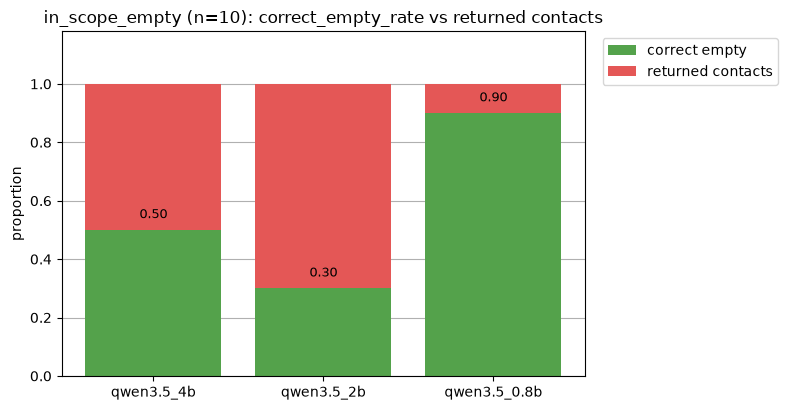

In [111]:
# in_scope_empty: one stacked bar per model (correct empty vs returned contacts)
empty_pivot = pivot_bucket(EMPTY_BUCKET, ["correct_empty_rate"])
correct = empty_pivot["correct_empty_rate"].reindex(models).fillna(0).clip(lower=0, upper=1)
returned = (1 - correct).clip(lower=0)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(models, correct, color="#54A24B", label="correct empty")
ax.bar(models, returned, bottom=correct, color="#E45756", label="returned contacts")
for x, v in enumerate(correct):
    ax.text(x, min(float(v), 1.0) + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_ylabel("proportion")
ax.set_xlabel("")
ax.set_title("in_scope_empty (n=10): correct_empty_rate vs returned contacts")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

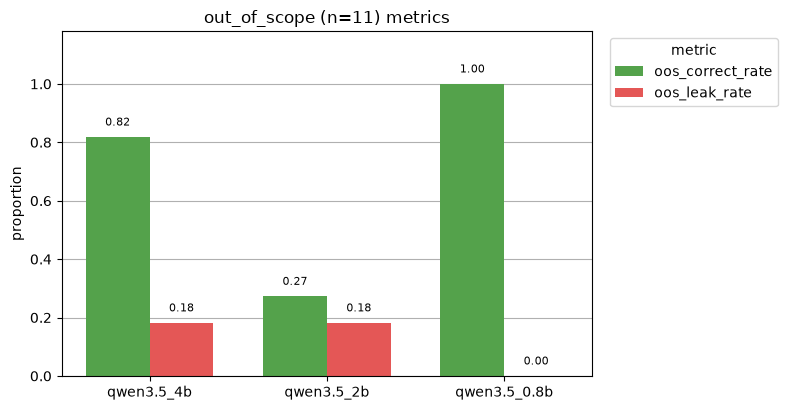

In [112]:
# oos: grouped bars for correct vs leak classification
oos_metrics = ["oos_correct_rate", "oos_leak_rate"]
oos_pivot = pivot_bucket(OOS_BUCKET, oos_metrics)

fig, ax = plt.subplots(figsize=(8, 4.2))
plot_grouped_rates(
    ax,
    oos_pivot,
    title="out_of_scope (n=11) metrics",
    colours={"oos_correct_rate": "#54A24B", "oos_leak_rate": "#E45756"},
)
plt.tight_layout()
plt.show()

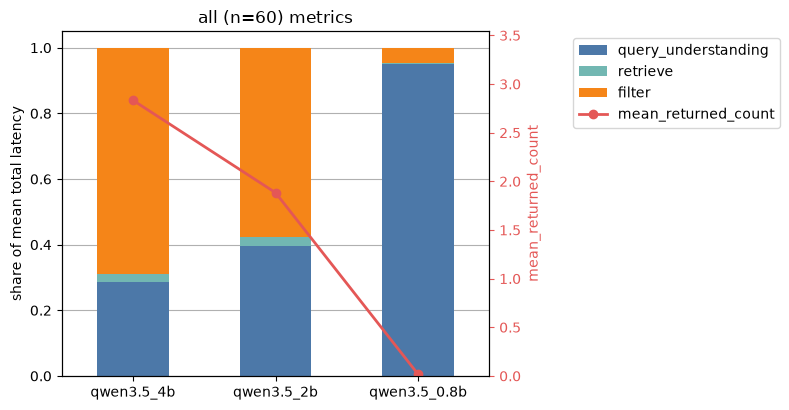

In [113]:
# all 60: stacked latency share, with mean_returned_count as a red line on a second y-axis
stage_cols = ["latency_ms_qu", "latency_ms_retrieve", "latency_ms_filter"]
stage_names = {
    "latency_ms_qu": "query_understanding",
    "latency_ms_retrieve": "retrieve",
    "latency_ms_filter": "filter",
}
stage_ms = (
    scored.set_index("model")[stage_cols]
    .fillna(0)
    .groupby(level=0)
    .mean()
    .reindex(index=models)
    .rename(columns=stage_names)
)
stage_share = stage_ms.div(stage_ms.sum(axis=1), axis=0)
returned = (
    pivot_bucket(ALL_BUCKET, ["mean_returned_count"])["mean_returned_count"]
    .reindex(models)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(8.4, 4.2))
stage_share.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    rot=0,
    color=["#4C78A8", "#72B7B2", "#F58518"],
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("share of mean total latency")
ax.set_xlabel("")
ax.set_title("all (n=60) metrics")
ax.grid(axis="y")
ax.set_axisbelow(True)

ax_count = ax.twinx()
xs = list(range(len(models)))
line = ax_count.plot(
    xs,
    returned.to_numpy(),
    color="#E45756",
    marker="o",
    linewidth=2,
    label="mean_returned_count",
)
ax_count.set_ylabel("mean_returned_count", color="#E45756")
ax_count.tick_params(axis="y", colors="#E45756")
ax_count.set_ylim(0, max(float(returned.max()) * 1.25, 1.0))

bar_handles, bar_labels = ax.get_legend_handles_labels()
ax.legend(
    bar_handles + line,
    bar_labels + ["mean_returned_count"],
    bbox_to_anchor=(1.18, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()